In [1]:
# Basic libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inline
%matplotlib inline


In [2]:
df = pd.read_csv('../data/raw/fraudTest.csv')

# Quick look
df.head()


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0


In [3]:
# Info about dataset
df.info()

# Summary statistics
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 555719 entries, 0 to 555718
Data columns (total 23 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             555719 non-null  int64  
 1   trans_date_trans_time  555719 non-null  object 
 2   cc_num                 555719 non-null  int64  
 3   merchant               555719 non-null  object 
 4   category               555719 non-null  object 
 5   amt                    555719 non-null  float64
 6   first                  555719 non-null  object 
 7   last                   555719 non-null  object 
 8   gender                 555719 non-null  object 
 9   street                 555719 non-null  object 
 10  city                   555719 non-null  object 
 11  state                  555719 non-null  object 
 12  zip                    555719 non-null  int64  
 13  lat                    555719 non-null  float64
 14  long                   555719 non-nu

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,555719.000000,5.557190e+05,555719.000000,555719.000000,555719.000000,555719.000000,5.557190e+05,5.557190e+05,555719.000000,555719.000000,555719.000000
mean,277859.000000,4.178387e+17,69.392810,48842.628015,38.543253,-90.231325,8.822189e+04,1.380679e+09,38.542798,-90.231380,0.003860
std,160422.401459,1.309837e+18,156.745941,26855.283328,5.061336,13.721780,3.003909e+05,5.201104e+06,5.095829,13.733071,0.062008
min,0.000000,6.041621e+10,1.000000,1257.000000,20.027100,-165.672300,2.300000e+01,1.371817e+09,19.027422,-166.671575,0.000000
25%,138929.500000,1.800429e+14,9.630000,26292.000000,34.668900,-96.798000,7.410000e+02,1.376029e+09,34.755302,-96.905129,0.000000
50%,277859.000000,3.521417e+15,47.290000,48174.000000,39.371600,-87.476900,2.408000e+03,1.380762e+09,39.376593,-87.445204,0.000000
75%,416788.500000,4.635331e+15,83.010000,72011.000000,41.894800,-80.175200,1.968500e+04,1.385867e+09,41.954163,-80.264637,0.000000
max,555718.000000,4.992346e+18,22768.110000,99921.000000,65.689900,-67.950300,2.906700e+06,1.388534e+09,66.679297,-66.952026,1.000000


In [4]:
# Missing values per column
df.isnull().sum()

Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

is_fraud
0    553574
1      2145
Name: count, dtype: int64
is_fraud
0    0.99614
1    0.00386
Name: proportion, dtype: float64


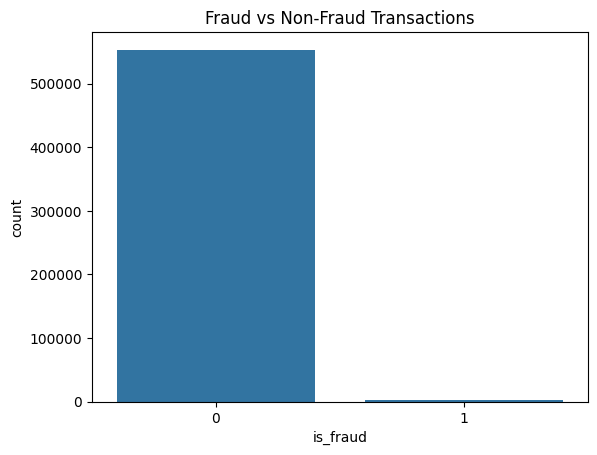

In [5]:
# Distribution of target
print(df['is_fraud'].value_counts())
print(df['is_fraud'].value_counts(normalize=True))

# Plot
sns.countplot(x='is_fraud', data=df)
plt.title('Fraud vs Non-Fraud Transactions')
plt.show()


In [6]:
# Numeric features
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
print("Numeric Columns:", numeric_cols)

# Categorical features
categorical_cols = df.select_dtypes(include='object').columns.tolist()
print("Categorical Columns:", categorical_cols)

Numeric Columns: ['Unnamed: 0', 'cc_num', 'amt', 'zip', 'lat', 'long', 'city_pop', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud']
Categorical Columns: ['trans_date_trans_time', 'merchant', 'category', 'first', 'last', 'gender', 'street', 'city', 'state', 'job', 'dob', 'trans_num']


In [7]:
print(max(df['amt']))

22768.11


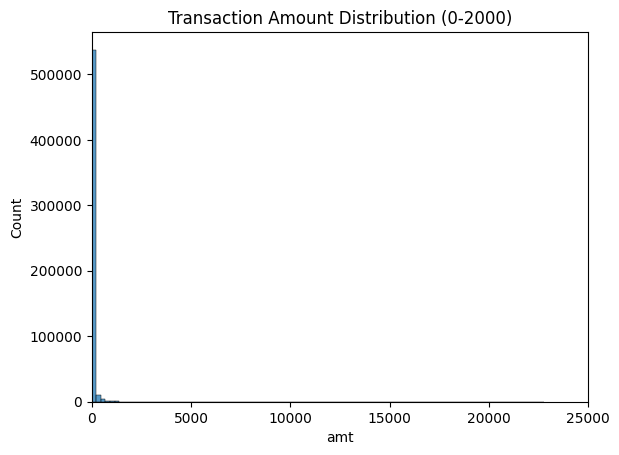

In [8]:
sns.histplot(df['amt'], bins=100)
plt.xlim(0, 25000)  
plt.title('Transaction Amount Distribution (0-2000)')
plt.show()

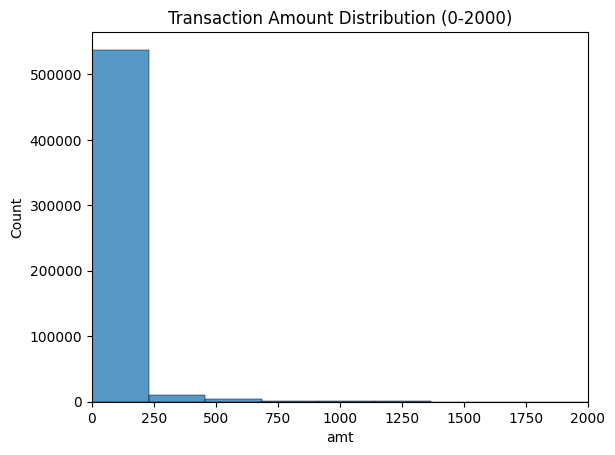

In [9]:
sns.histplot(df['amt'], bins=100)
plt.xlim(0, 2000)  # focus on most data
plt.title('Transaction Amount Distribution (0-2000)')
plt.show()

In [10]:
target = 'is_fraud'

In [11]:
df['is_fraud'].value_counts(normalize=True) * 100

is_fraud
0    99.614014
1     0.385986
Name: proportion, dtype: float64

In [12]:
df['is_fraud'].value_counts()

is_fraud
0    553574
1      2145
Name: count, dtype: int64

In [13]:
df.groupby('is_fraud')['amt'].describe()

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,553574.0,67.614408,152.471931,1.00,9.60,47.15,82.62,22768.11
1,2145.0,528.356494,392.747594,1.78,214.51,371.94,907.77,1320.92


In [14]:
#we can see that the average amount of fraud transaction is higher and similar in variance

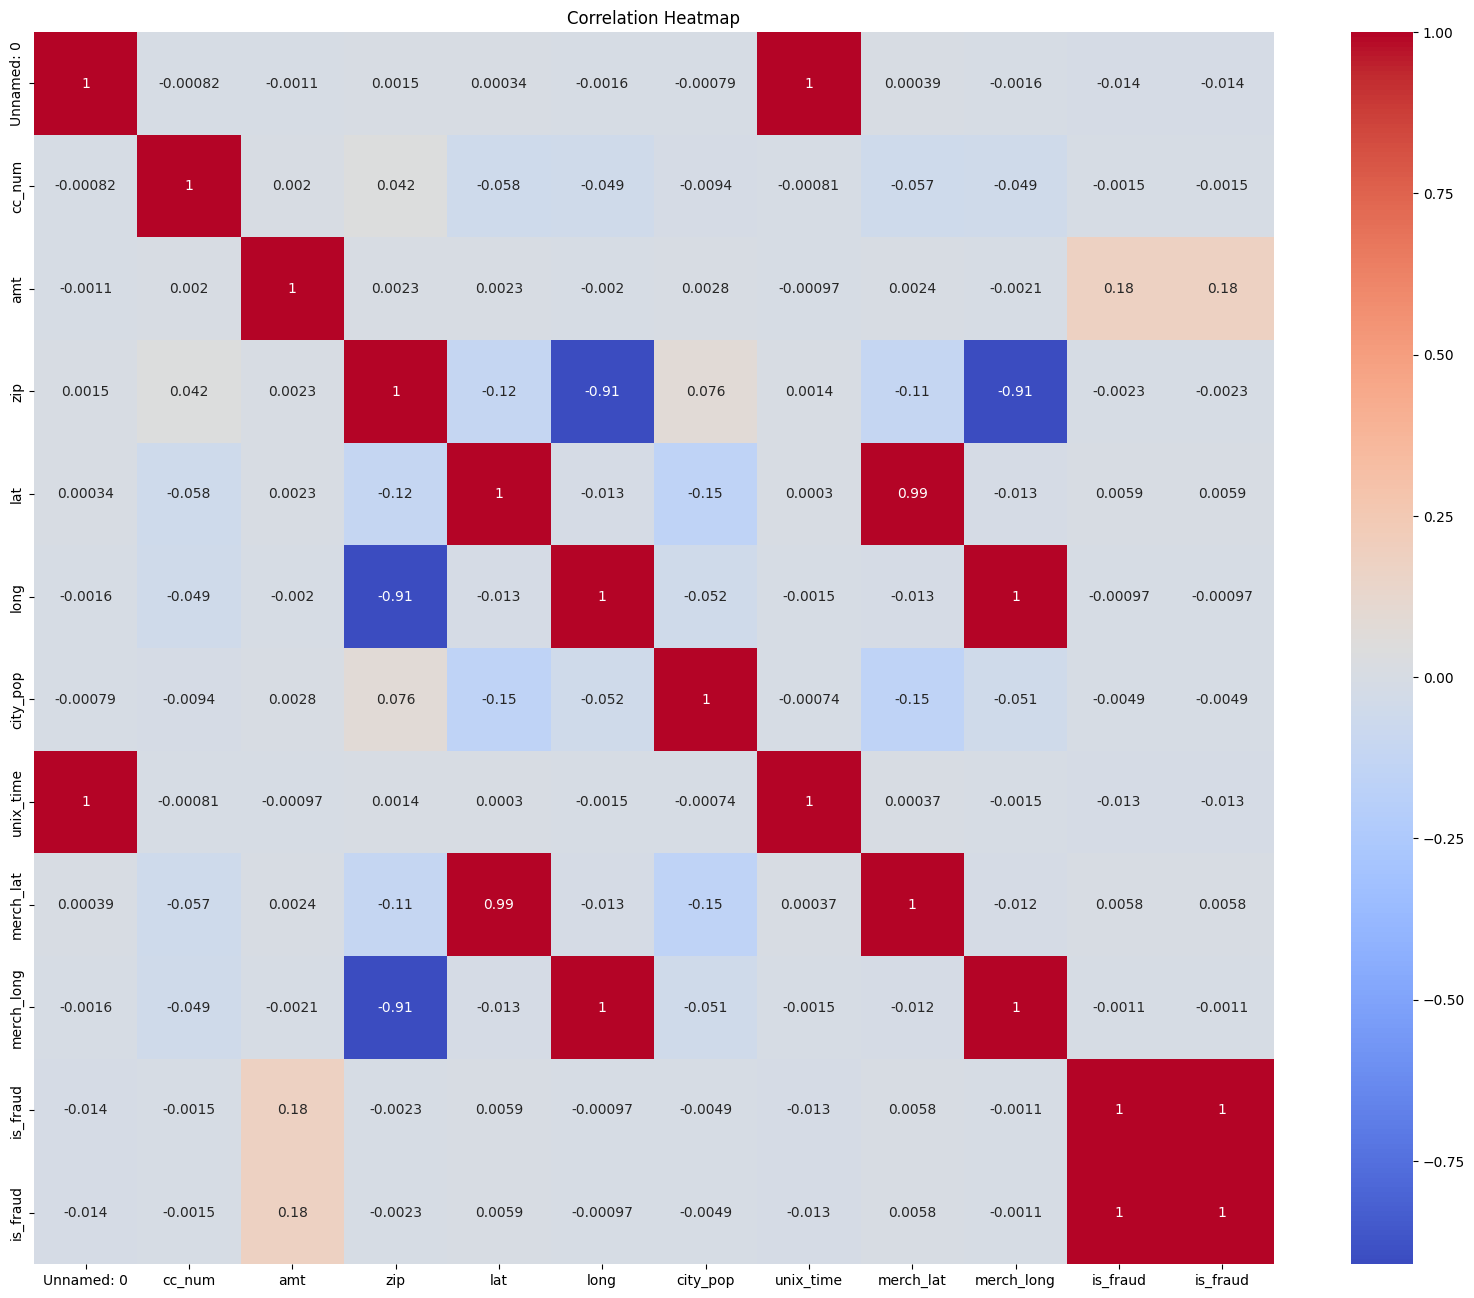

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df[numeric_cols + ['is_fraud']].corr()

plt.figure(figsize=(20,16))
sns.heatmap(corr, annot=True, cmap='coolwarm')
# sns.heatmap(corr, annot=True, cmap='coolwarm',fmt=".0%")
plt.title("Correlation Heatmap")
plt.show()
# correlation with target

In [16]:
df.groupby('gender')['is_fraud'].mean()
df.groupby('category')['is_fraud'].mean().sort_values(ascending=False).head(10)
#Categorical feature vs fraud rate

category
shopping_net     0.012111
misc_net         0.009756
grocery_pos      0.009229
shopping_pos     0.004278
gas_transport    0.002732
travel           0.002292
grocery_net      0.002111
misc_pos         0.002082
personal_care    0.001780
entertainment    0.001471
Name: is_fraud, dtype: float64

In [17]:
fraud_df = df[df['is_fraud'] == 1][
    [ 'amt', 'merchant', 'category', 'state', 'trans_date_trans_time', 'gender', 'dob', 'job','city_pop']
]

In [18]:
fraud_df.head(20)

,amt,merchant,category,state,trans_date_trans_time,gender,dob,job,city_pop
1685,24.84,fraud_Hamill-D'Amore,health_fitness,TX,2020-06-21 22:06:39,F,1969-09-15,Cytogeneticist,23
1767,780.52,"fraud_Rodriguez, Yost and Jenkins",misc_net,WI,2020-06-21 22:32:22,M,1958-09-10,Public relations officer,1306
1781,620.33,fraud_Nienow PLC,entertainment,WI,2020-06-21 22:37:27,M,1958-09-10,Public relations officer,1306
1784,1077.69,"fraud_Heathcote, Yost and Kertzmann",shopping_net,LA,2020-06-21 22:38:55,M,1994-05-31,Herbalist,71335
1857,842.65,fraud_Hermann and Sons,shopping_pos,TX,2020-06-21 23:02:16,F,1969-09-15,Cytogeneticist,23
1891,22.55,fraud_Thompson-Gleason,health_fitness,FL,2020-06-21 23:16:12,F,1986-05-07,"Librarian, public",105638
1906,1128.26,fraud_Kuhic LLC,shopping_net,LA,2020-06-21 23:21:44,M,1994-05-31,Herbalist,71335
1956,931.82,"fraud_Reichert, Rowe and Mraz",shopping_net,LA,2020-06-21 23:35:27,M,1994-05-31,Herbalist,71335
1968,983.00,"fraud_Kihn, Abernathy and Douglas",shopping_net,LA,2020-06-21 23:40:26,M,1994-05-31,Herbalist,71335
2026,955.16,fraud_Lemke-Gutmann,shopping_net,WI,2020-06-21 23:59:05,M,1958-09-10,Public relations officer,1306
